In [55]:
from langgraph.graph import StateGraph, START,END
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from typing import TypedDict,Dict,List,Literal

In [56]:
class QuadraticState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str

In [57]:
def show_equation(state: QuadraticState)->Dict:
    a = state['a']
    b = state['b']
    c = state['c']
    if b > 0:
        b= f'+ {b}'
    if c > 0:
        c= f'+ {c}'
    equation = f"{a} X^2 {b} X {c}"
    return {
        'equation':equation
    }

def discriminant(state: QuadraticState)->Dict:
    a = state['a']
    b = state['b']
    c = state['c']
    result = (b**2 )- (4 * a * c)
    return {
        'discriminant':result
    }
def router(state: QuadraticState)->Literal['real_roots','repeated_roots','no_real_roots']:
    discriminant = state['discriminant']
    if (discriminant==0):
        return 'repeated_roots'
    elif (discriminant>0):
        return 'real_roots'
    elif (discriminant<0):
        return 'no_real_roots'

def real_roots(state: QuadraticState)->Dict:
    a = state['a']
    b = state['b']
    c = state['c']
    discriminant = state['discriminant']

    root1 = - (b + (discriminant**0.5))/(2*a)
    root2 = - (b - (discriminant**0.5))/(2*a)
    return {
        'result' : f"therefore the roots of the equation are {root1} and {root2}"
    }

def repeated_roots(state: QuadraticState)->Dict:
    a = state['a']
    b = state['b']
    c = state['c']
    discriminant = state['discriminant']

    root1 = - (b/(2*a))
    return {
        'result' : f"therefore the root of the equation is {root1}"
    }

def no_real_roots(state: QuadraticState)->Dict:

    return {
        'result' : f"No real roots exists for the given equation "
    }

In [58]:
graph = StateGraph(QuadraticState)
graph.add_node('show equation',show_equation)
graph.add_node('discriminant',discriminant)
# graph.add_node('router', router)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START,'show equation')
graph.add_edge('show equation','discriminant')

graph.add_conditional_edges('discriminant',router)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)


In [59]:
workflow= graph.compile()

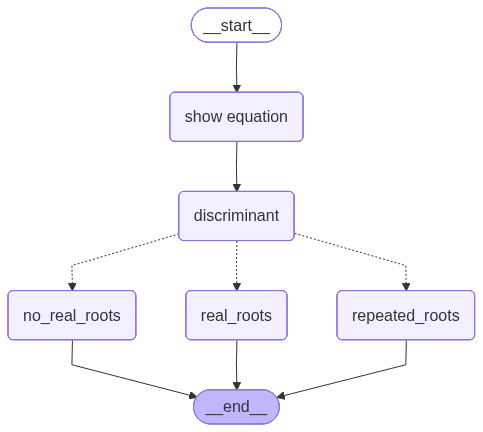

In [60]:
workflow

In [61]:
app= graph.compile()

In [62]:
app.invoke({
    'a':3,
    'b':4,
    'c':5
})

{'a': 3,
 'b': 4,
 'c': 5,
 'equation': '3 X^2 + 4 X + 5',
 'discriminant': -44,
 'result': 'No real roots exists for the given equation '}